# Modelos de Regresión Lineal
## Modelo con datos simulados
* y = a + b * x
* X : 100 valores distribuídos según una N(1.5, 2.5)

  (media = 1.5 y desviación estándar = 2.5)
* Ye = 5 + 1.9 * x + e
* e estará distribuído según una N(0, 0.8)

  Nota: "e" se refiere al error calculado en `y`.

In [67]:
import pandas as pd
import numpy as np

In [68]:
x = 1.5 + 2.5 * np.random.randn(100)

In [69]:
e = 0 + 0.8 * np.random.randn(100)

In [70]:
y_est = 5 + 1.9 * x

In [71]:
y_real = y_est + e

In [72]:
x_list = x.tolist()
y_est_list = y_est.tolist()
y_real_list = y_real.tolist()

In [73]:
data = pd.DataFrame({
                    "x": x_list,
                    "y-estimada": y_est_list,
                    "y-real": y_real_list
                    })

In [74]:
data.head()

,x,y-estimada,y-real
0,-1.046255,3.012116,2.939872
1,-0.923449,3.245448,2.263970
2,4.305456,13.180367,13.527208
3,1.627669,8.092571,8.682586
4,0.006916,5.013141,5.033085


In [75]:
import matplotlib.pyplot as plt

In [76]:
'''
Definimos una lista, cuyos elementos son
todos la media de los valores reales de y.
'''

y_real_mean_list = [np.mean(y_real) for i in range(len(x_list))]

In [77]:
y_real_mean_list

[8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,
 8.382094922320421,


Text(0.5, 1.0, 'Valor Actual vs Predicción')

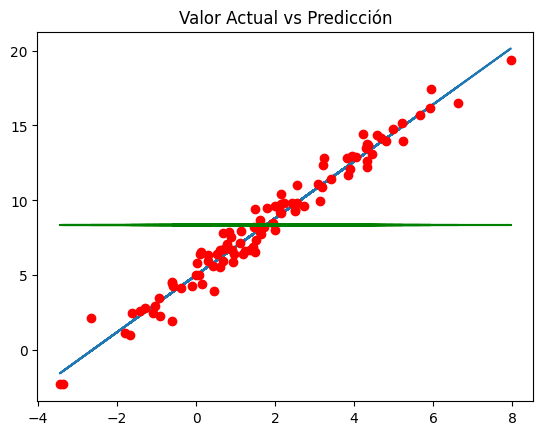

In [78]:
%matplotlib inline
plt.plot(data["x"], data["y-estimada"])
plt.plot(data["x"], data["y-real"], "ro")
plt.plot(data["x"], y_real_mean_list, "g")
plt.title("Valor Actual vs Predicción")

Text(0.5, 1.0, 'Valor Actual vs Predicción')

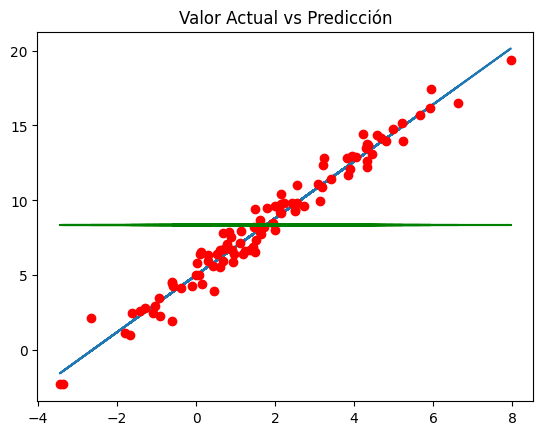

In [79]:
# No se observa diferencia si quito "%matplotlib inline"

plt.plot(data["x"], data["y-estimada"])
plt.plot(data["x"], data["y-real"], "ro")
plt.plot(data["x"], y_real_mean_list, "g")
plt.title("Valor Actual vs Predicción")

## ¿Como es la predicción de buena?
* SST = SSD + SSR
* SST : Variabilidad de los datos con respecto de su media
* SSD : Diferencia entre los datos originales y las predicciones que el modelo no es capaz de explicar (errores que deberían seguir una distribución normal)
* SSR : Diferencia entre la regresión y el valor medio que el modelo busca explicar
* R2 = SSR / SST, coeficiente de determinación entre 0 y 1

In [80]:
y_real_mean = np.mean(y_real)
data["SSR-término"]=(data["y-estimada"] - y_real_mean) ** 2
data["SSD-término"]=(data["y-estimada"] - data["y-real"]) ** 2
data["SST-término"]=(data["y-real"] - y_real_mean) ** 2

In [81]:
data.head()

,x,y-estimada,y-real,SSR-término,SSD-término,SST-término
0,-1.046255,3.012116,2.939872,28.836669,0.005219,29.617794
1,-0.923449,3.245448,2.263970,26.385144,0.963299,37.431454
2,4.305456,13.180367,13.527208,23.023416,0.120299,26.472193
3,1.627669,8.092571,8.682586,0.083824,0.348119,0.090295
4,0.006916,5.013141,5.033085,11.349849,0.000398,11.215869


In [82]:
SST = np.sum(data["SST-término"])
SSD = np.sum(data["SSD-término"])
SSR = np.sum(data["SSR-término"])

In [83]:
SST

1820.6084845873847

In [84]:
SSD

61.46253042535139

In [85]:
SSR

1764.242793339983

In [86]:
SSR + SSD

1825.7053237653345

In [87]:
R2 = SSR / SST

In [88]:
R2

0.9690401908347823

(array([ 2.,  2., 15., 15., 17., 21., 15.,  8.,  4.,  1.]),
 array([-1.93015675, -1.51931523, -1.10847372, -0.6976322 , -0.28679069,
         0.12405083,  0.53489235,  0.94573386,  1.35657538,  1.76741689,
         2.17825841]),
 <BarContainer object of 10 artists>)

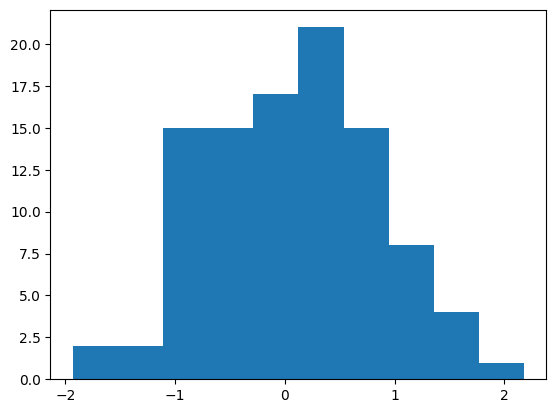

In [89]:
# Representemos la distribución del error:
plt.hist(data["y-real"] - data["y-estimada"])

## Obteniendo la recta de regresión

* y = a + b * x
* b = sum((xi - x_mean)*(y_i - y_mean))/sum((xi - x_mean)^2)
* a = y_mean - b * x_mean

In [90]:
x_mean = np.mean(data["x"])
y_mean = np.mean(data["y-real"])
x_mean, y_mean

(1.7413645457509352, 8.382094922320421)

In [91]:
data["covarianza-término"] = (data["x"] - x_mean) * (data["y-real"] - y_mean)
data["varianza-x-término"] = (data["x"] - x_mean) ** 2

In [92]:
beta = np.sum(data["covarianza-término"]) / np.sum(data["varianza-x-término"])

In [93]:
alpha = y_mean - beta * x_mean

In [94]:
beta, alpha

(1.897836649995194, 5.077269466392064)

In [95]:
data["y_modelo"] = alpha + beta * data["x"]

In [96]:
data.head()

,x,y-estimada,y-real,SSR-término,SSD-término,SST-término,covarianza-término,varianza-x-término,y_modelo
0,-1.046255,3.012116,2.939872,28.836669,0.005219,29.617794,15.170845,7.770820,3.091649
1,-0.923449,3.245448,2.263970,26.385144,0.963299,37.431454,16.303660,7.101229,3.324715
2,4.305456,13.180367,13.527208,23.023416,0.120299,26.472193,13.192543,6.574567,13.248322
3,1.627669,8.092571,8.682586,0.083824,0.348119,0.090295,-0.034165,0.012927,8.166319
4,0.006916,5.013141,5.033085,11.349849,0.000398,11.215869,5.808684,3.008310,5.090396


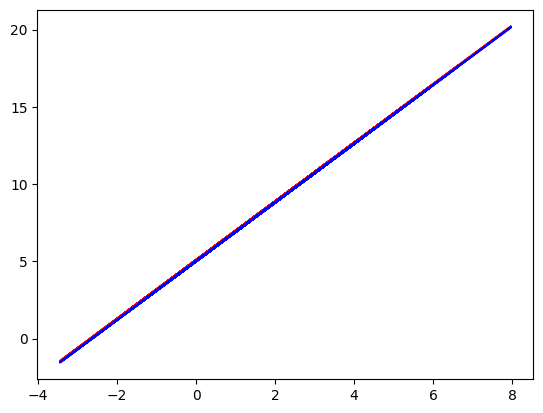

In [97]:
# Contrastando los dos procedimientos:
%matplotlib inline
plt.plot(data["x"], data["y_modelo"], "r")
plt.plot(data["x"], data["y-estimada"], "b")

In [98]:
# Calculamos nuevos SSR, SSD, SST:
y_real_mean = np.mean(y_real)
data["SSR-término-new"] = (data["y_modelo"] - y_real_mean) ** 2
data["SSD-término-new"] = (data["y_modelo"] - data["y-real"]) ** 2
data["SST-término-new"] = (data["y-real"] - y_real_mean) ** 2

In [99]:
SST_new = np.sum(data["SST-término-new"])
SSD_new = np.sum(data["SSD-término-new"])
SSR_new = np.sum(data["SSR-término-new"])

In [100]:
SST_new, SSD_new, SSR_new

(1820.6084845873847, 60.919985326861365, 1759.688499260524)

In [101]:
R2_new = SSR_new / SST_new

In [102]:
R2_new

0.9665386677901441

In [103]:
SST, SST_new

(1820.6084845873847, 1820.6084845873847)

In [104]:
SSD, SSD_new

(61.46253042535139, 60.919985326861365)

In [105]:
SSR, SSR_new

(1764.242793339983, 1759.688499260524)

In [65]:
R2, R2_new

(0.9397385399667125, 0.9762718953929163)

In [106]:
data.head()

,x,y-estimada,y-real,SSR-término,SSD-término,SST-término,covarianza-término,varianza-x-término,y_modelo,SSR-término-new,SSD-término-new,SST-término-new
0,-1.046255,3.012116,2.939872,28.836669,0.005219,29.617794,15.170845,7.770820,3.091649,27.988815,0.023036,29.617794
1,-0.923449,3.245448,2.263970,26.385144,0.963299,37.431454,16.303660,7.101229,3.324715,25.577092,1.125180,37.431454
2,4.305456,13.180367,13.527208,23.023416,0.120299,26.472193,13.192543,6.574567,13.248322,23.680169,0.077777,26.472193
3,1.627669,8.092571,8.682586,0.083824,0.348119,0.090295,-0.034165,0.012927,8.166319,0.046559,0.266532,0.090295
4,0.006916,5.013141,5.033085,11.349849,0.000398,11.215869,5.808684,3.008310,5.090396,10.835284,0.003285,11.215869


## Error estándar de los residuos (RSE)

In [107]:
RSE1 = np.sqrt(SSD/(len(data) - 2))
RSE2 = np.sqrt(SSD_new/(len(data) - 2))

In [108]:
RSE1, RSE2

(0.7919398195631459, 0.7884367465658358)

In [109]:
RSE1 / np.mean(data["y-real"])

0.09447993931139026

In [110]:
RSE2 / np.mean(data["y-real"])

0.09406201598437307

# NOTA: El segundo procedimiento ha resultado muy bueno!